In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns 
from string import punctuation
from ydata_profiling import ProfileReport
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
import xgboost as xgb
import catboost as cb
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, RandomizedSearchCV




In [2]:
df=pd.read_csv('SMSSpamCollection',sep='\t', header=None, names=['label','message'])

In [3]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
profile=ProfileReport(df)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00,  6.95it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [5]:
stp_english = stopwords.words('english')
lm = WordNetLemmatizer()

In [6]:
def message_clean(text):
    text=text.lower()
    text=text.strip()
    text=''.join([i for i in text if i not in punctuation])
    text=word_tokenize(text)
    text=[i for i in text if i not in stp_english]
    text=[lm.lemmatize(i) for i in text]
    return text

In [7]:
df['message_final']=df['message'].apply(lambda x: message_clean(x))

In [8]:
tf=TfidfVectorizer()
x=tf.fit_transform(df['message_final'].apply(lambda x: ' '.join(x)))
var=pd.DataFrame(x.toarray(), columns=tf.get_feature_names_out())
var.head()

,008704050406,0089my,0121,01223585236,01223585334,0125698789,02,020603,0207,02070836089,...,zero,zhong,zindgi,zoe,zogtorius,zoom,zouk,zyada,üll,〨ud
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
def len_message(text):
    text=len(text)
    return text
df['len_message']=df['message'].apply(lambda x: len_message(x))
df.head()

,label,message,message_final,len_message
0,ham,"Go until jurong point, crazy.. Available only ...","[go, jurong, point, crazy, available, bugis, n...",111
1,ham,Ok lar... Joking wif u oni...,"[ok, lar, joking, wif, u, oni]",29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entry, 2, wkly, comp, win, fa, cup, fin...",155
3,ham,U dun say so early hor... U c already then say...,"[u, dun, say, early, hor, u, c, already, say]",49
4,ham,"Nah I don't think he goes to usf, he lives aro...","[nah, dont, think, go, usf, life, around, though]",61


In [10]:
df['len_message'].describe()

count    5572.000000
mean       80.489950
std        59.942907
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: len_message, dtype: float64

In [11]:
df[df['len_message']<10].head(10)

,label,message,message_final,len_message
131,ham,I'm home.,"[im, home]",9
261,ham,Yup,[yup],3
276,ham,Thanx...,[thanx],8
284,ham,Okie...,[okie],7
287,ham,Ok..,[ok],4
632,ham,Thank u!,"[thank, u]",8
783,ham,Beerage?,[beerage],8
960,ham,Where @,[],7
1273,ham,Ok...,[ok],5
1319,ham,Ok...,[ok],5


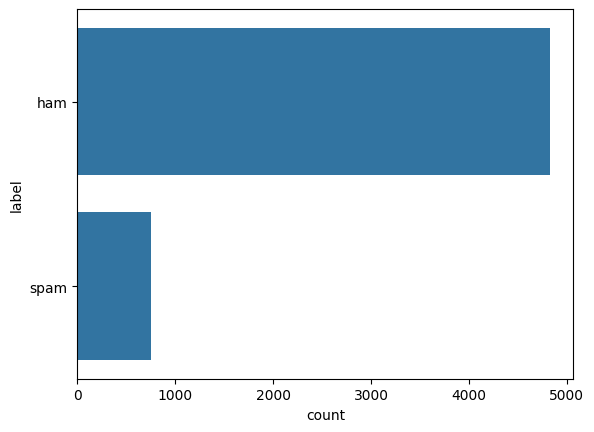

In [12]:
sns.countplot(df['label'])
plt.show()

In [13]:
df[['len_message','label']].groupby('label').describe()

len_message                                                         
            count        mean        std   min    25%    50%    75%    max
label                                                                     
ham        4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0
spam        747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0

<Axes: xlabel='len_message', ylabel='Count'>

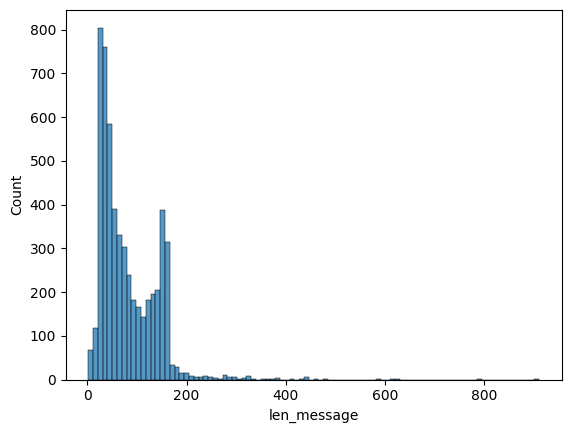

In [14]:
sns.histplot(df['len_message'])

<Axes: xlabel='label', ylabel='len_message'>

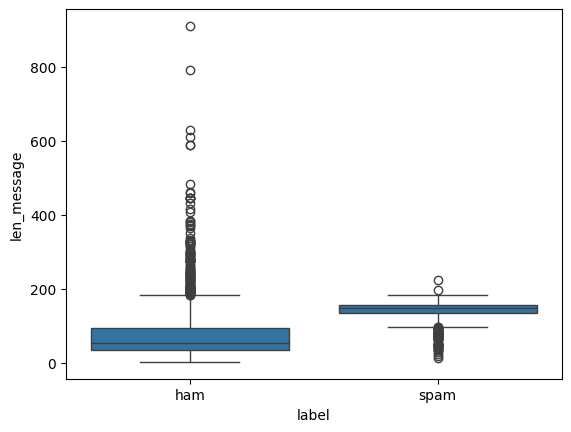

In [15]:
sns.boxplot(x='label',y='len_message',data=df)

In [16]:
df_final=pd.concat([var,df['len_message'],df['label']],axis=1)

In [17]:
df_final.isna().sum()   

008704050406    0
0089my          0
0121            0
01223585236     0
01223585334     0
               ..
zyada           0
üll             0
〨ud             0
len_message     0
label           0
Length: 8904, dtype: int64

In [18]:
df_final.head()

,008704050406,0089my,0121,01223585236,01223585334,0125698789,02,020603,0207,02070836089,...,zindgi,zoe,zogtorius,zoom,zouk,zyada,üll,〨ud,len_message,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,111,ham
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29,ham
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,155,spam
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49,ham
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,61,ham


In [19]:
x=df_final.drop('label',axis=1)
y=df_final['label']

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [21]:
rf_model=RandomForestClassifier(n_estimators=300,n_jobs=-1,random_state=42)
rf_model.fit(x_train,y_train)
y_pred_rf=rf_model.predict(x_test)
accuracy_rf=accuracy_score(y_test,y_pred_rf)
accuracy_rf

0.9811659192825112

In [22]:
sorted(zip(rf_model.feature_importances_, x.columns), reverse=True)[0:10]

[(0.04784219181890274, 'len_message'),
 (0.034935299942766986, 'call'),
 (0.022640864303107657, 'mobile'),
 (0.020738313490256843, 'txt'),
 (0.020469090423949895, 'free'),
 (0.019762405100033135, 'claim'),
 (0.015831087061877882, 'stop'),
 (0.014310580628938434, 'service'),
 (0.01330355583554114, 'prize'),
 (0.012224436570928062, 'reply')]

In [23]:
svm_model=svm.SVC(kernel='rbf', random_state=42, class_weight='balanced')
svm_model.fit(x_train,y_train)
y_pred_svm=svm_model.predict(x_test)
accuracy_svm=accuracy_score(y_test,y_pred_svm)
accuracy_svm

0.8251121076233184

In [24]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train,y_train)
y_pred_knn=knn_model.predict(x_test)
accuracy_knn=accuracy_score(y_test,y_pred_knn)
accuracy_knn

0.9255605381165919

In [25]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  
y_test_encoded  = le.transform(y_test)

In [26]:
xgb_model=xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(x_train,y_train_encoded)
y_pred_xgb=xgb_model.predict(x_test)
accuracy_xgb=accuracy_score(y_test_encoded,y_pred_xgb)
accuracy_xgb

0.9739910313901345

In [27]:
cb_model=cb.CatBoostClassifier(random_state=42, verbose=0)
cb_model.fit(x_train,y_train)
y_pred_cb=cb_model.predict(x_test)
accuracy_cb=accuracy_score(y_test,y_pred_cb)
accuracy_cb

0.9739910313901345

In [28]:
lgb_model=lgb.LGBMClassifier(random_state=42)
lgb_model.fit(x_train,y_train)
y_pred_lgb=lgb_model.predict(x_test)
accuracy_lgb=accuracy_score(y_test,y_pred_lgb)
accuracy_lgb

[LightGBM] [Info] Number of positive: 598, number of negative: 3859
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7001
[LightGBM] [Info] Number of data points in the train set: 4457, number of used features: 366
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.134171 -> initscore=-1.864573
[LightGBM] [Info] Start training from score -1.864573


0.9811659192825112

In [32]:
mlp_model=MLPClassifier(hidden_layer_sizes=(256,128,64), random_state=42, max_iter=100,solver='adam')
mlp_model.fit(x_train,y_train)
y_pred_mlp=mlp_model.predict(x_test)
accuracy_mlp=accuracy_score(y_test,y_pred_mlp)
accuracy_mlp

0.9865470852017937

In [51]:
log_model=LogisticRegression(random_state=42, max_iter=1000)

param_grid = {
    'C': [0.1, 1],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
}

In [54]:
random_search = RandomizedSearchCV(
    estimator=log_model,              
    param_distributions=param_grid,
    n_iter=10,                    
    cv=2,         
    scoring='accuracy',           
    n_jobs=-1,                    
    verbose=1,                    
    random_state=42
)
random_search.fit(x_train, y_train)
best_log_model = random_search.best_estimator_
y_pred_log=best_log_model.predict(x_test)
accuracy_log=accuracy_score(y_test,y_pred_log)

c:\Users\Administrator\datascience-env\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 2 folds for each of 8 candidates, totalling 16 fits


c:\Users\Administrator\datascience-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Administrator\datascience-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [55]:
accuracy_log

0.9596412556053812